---
authors:
  - name: Patrick Erdelt
    email: perdelt@bht-berlin.de
  - name: Felix Bießmann
    email: felix.biessmann@bht-berlin.de
  - name: Leonhard Liu
    email: leonhard.liu@bht-berlin.de
downloads:
  - file: ./session10_two_tower_multimodal.slides.html
    title: Session 10 Slides (HTML)
---

# Session 10: Two-Tower, Multimodal Embeddings & Retrieval

> *"Text, ratings — and now images — all into one space. Two towers, one dot product."*

**Core idea:** a **two-tower** model learns **one encoder per side** that maps its input into **one shared
space**, scored by a dot product. It's the trick behind MF, autoencoders and Sentence-Transformers, now extended
to **images** — and we open the **vision encoder** to see how a picture becomes a vector.

In [1]:
# Setup — run this first.  (torch, sentence-transformers, scikit-image, chromadb are in the course
# .venv; the CLIP model is cached locally so this is fast and offline.)
import os, warnings; warnings.filterwarnings('ignore')
os.environ['HF_HUB_OFFLINE'] = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
import logging; logging.getLogger('sentence_transformers').setLevel(logging.ERROR)  # no encode() progress bars
from transformers.utils import logging as _hflog; _hflog.disable_progress_bar()      # no model-load progress widgets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')          # crisp vector figures that stay sharp at any browser zoom
from matplotlib.patches import Rectangle, FancyBboxPatch
from PIL import Image
from skimage import data
from skimage.transform import resize
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 13, 'axes.titlesize': 16})
BLUE, RED, GREEN, ORANGE, PURPLE, PINK = '#1976d2', '#d32f2f', '#388e3c', '#f57c00', '#7b1fa2', '#e91e63'
np.random.seed(42)

# A small, reproducible image set (scikit-image's bundled photos) — stand-ins for movie posters
# until the TMDB poster fetch is wired up. CLIP only needs PIL images.
IMG_NAMES  = ['astronaut', 'chelsea', 'coffee', 'rocket', 'hubble_deep_field', 'camera']
IMG_LABELS = ['astronaut', 'cat', 'coffee', 'rocket', 'galaxies', 'photographer']
def _as_rgb(arr):
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)          # camera is grayscale -> 3 channels
    return Image.fromarray(arr)
IMAGES = [_as_rgb(getattr(data, n)()) for n in IMG_NAMES]

# CLIP: ONE model, encodes BOTH images and text into the SAME 512-d space (same .encode() API as S9).
from sentence_transformers import SentenceTransformer
clip = SentenceTransformer('clip-ViT-B-32')
print('CLIP ready — image & text share one 512-d space. Demo images:', ', '.join(IMG_NAMES))

CLIP ready — image & text share one 512-d space. Demo images: astronaut, chelsea, coffee, rocket, hubble_deep_field, camera


## Recap: every session has been turning things into vectors

- **S6–7:** items as **content vectors** (genres → cosine similarity).
- **S8:** **SVD / autoencoder** *learn* a user & item vector from the rating matrix.
- **S9:** **neural text embeddings** — any description → a vector; cold-start solved.
- **Today:** add **images**, and the **two-tower** frame that unifies all of them.

> Every method so far ends the same way: an entity becomes a point in a shared space and
> we compare points by dot product / cosine. Session 10 makes that frame explicit and adds a new
> *modality* — pixels — so a movie can be described by its **text, its poster, and its ratings** at once.

## What to take home — and what to just appreciate

This is the **finale**: a tour of how the whole arc fits together. Read each slide at its **tier**.

- **<span style="color:#388e3c">Core</span> — be able to explain these:**
  1. The **two-tower** pattern: two encoders → one **shared space** → a **dot-product** score.
  2. A **vision encoder (ViT)** turns an image into a vector; **CLIP** puts images & text in **one shared
     space**, compared by cosine.
  3. **Evaluation:** rank by embedding similarity, score it on held-out data with **Recall@k / NDCG@k** — and
     mind the **popularity trap** (best offline number ≠ best system).
  4. **Cold-start:** *content* embeddings (text, and now **images**) can place a brand-new item; pure
     *collaborative* signal cannot.
- **<span style="color:#1976d2">Awareness</span> — enjoy the idea, don't memorize the internals:** *how* all
  of these are **trained** (the contrastive loss & its N×N matrix, ViT objectives / MAE, SigLIP) ·
  **fusing** signals into one item vector · the deeper **offline-metric caveats** (MNAR, online A/B).

> Every slide is tagged **<span style="color:#388e3c">Core</span>** or **<span style="color:#1976d2">Awareness</span>**.
> If an Awareness slide feels dense, that's by design — follow the picture, not every formula.

## Recap (S9): how SBERT learns — contrastive training

<small><span style="color:#1976d2"><b>Awareness</b></span> — the one training trick behind the whole lecture.</small>

- SBERT is trained on **pairs that should mean the same**: (question, its duplicate), (sentence, its
  paraphrase), (query, a relevant answer). Each pair is a **positive**.
- The trick: in a batch of *N* pairs, each anchor's true partner is its positive — the **other N−1 partners
  are negatives** ("**in-batch negatives**" — free, no extra labelling).
- Score every anchor against every candidate → an **N×N cosine matrix**; the **diagonal** holds the true pairs.
- **Loss = softmax each row, then −log of the diagonal cell** — i.e. plain **cross-entropy** with "the right
  answer is the diagonal". It pulls the diagonal up and pushes the rest down.

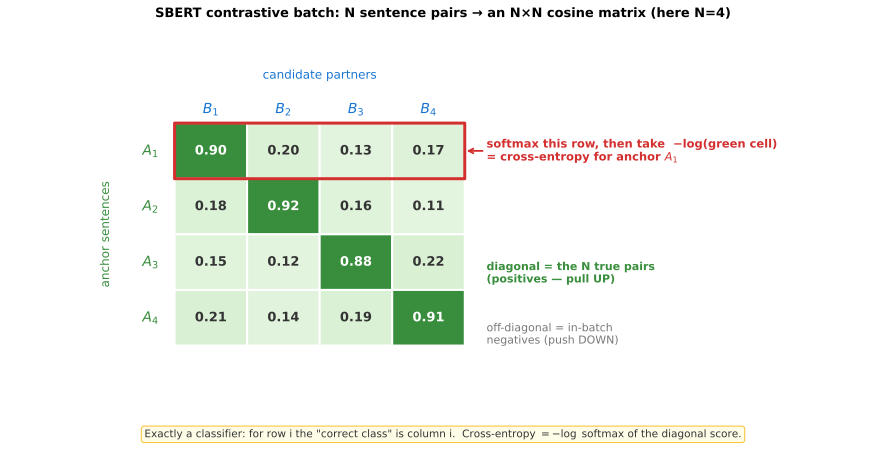

In [2]:
# Recap figure: SBERT's contrastive batch -> N x N cosine matrix; row-softmax + cross-entropy on the diagonal.
fig, ax = plt.subplots(figsize=(12.5, 6.8)); ax.axis('off')
ax.set_xlim(0, 12); ax.set_ylim(0, 8)
M = np.array([[0.90, 0.20, 0.13, 0.17],
              [0.18, 0.92, 0.16, 0.11],
              [0.15, 0.12, 0.88, 0.22],
              [0.21, 0.14, 0.19, 0.91]])
N, x0, ytop = 4, 2.3, 6.2
for r in range(N):
    for c in range(N):
        x, y = x0 + c, ytop - 1 - r
        diag = (r == c)
        fc = GREEN if diag else plt.cm.Greens(0.08 + 0.45 * M[r, c])
        ax.add_patch(Rectangle((x, y), 1, 1, facecolor=fc, edgecolor='white', lw=2))
        ax.text(x + 0.5, y + 0.5, f'{M[r, c]:.2f}', ha='center', va='center',
                fontsize=13, fontweight='bold', color='white' if diag else '#333')
for c in range(N):                                        # column = a candidate partner sentence
    ax.text(x0 + c + 0.5, ytop + 0.18, f'$B_{{{c+1}}}$', ha='center', fontsize=14, fontweight='bold', color=BLUE)
ax.text(x0 + N/2, ytop + 0.8, 'candidate partners', ha='center', fontsize=12, color=BLUE)
for r in range(N):                                        # row = an anchor sentence
    ax.text(x0 - 0.22, ytop - 1 - r + 0.5, f'$A_{{{r+1}}}$', ha='right', va='center', fontsize=14, fontweight='bold', color=GREEN)
ax.text(x0 - 0.95, ytop - N/2, 'anchor sentences', ha='center', va='center', rotation=90, fontsize=12, color=GREEN)
ax.add_patch(Rectangle((x0, ytop - 1), N, 1, fill=False, edgecolor=RED, lw=3))   # box the first row
ax.annotate('softmax this row, then take  −log(green cell)\n= cross-entropy for anchor $A_1$',
            xy=(x0 + N, ytop - 0.5), xytext=(x0 + N + 0.3, ytop - 0.5), va='center',
            fontsize=11.5, color=RED, fontweight='bold', arrowprops=dict(arrowstyle='->', color=RED, lw=1.8))
ax.text(x0 + N + 0.3, 3.5, 'diagonal = the N true pairs\n(positives — pull UP)', fontsize=11, color=GREEN, fontweight='bold', va='center')
ax.text(x0 + N + 0.3, 2.4, 'off-diagonal = in-batch\nnegatives (push DOWN)', fontsize=11, color='#777', va='center')
ax.text(6.0, 0.55, 'Exactly a classifier: for row i the "correct class" is column i.  '
        r'Cross-entropy $= -\log$ softmax of the diagonal score.',
        ha='center', fontsize=10.5, color='#333', bbox=dict(boxstyle='round', fc='#fffde7', ec='#fbc02d'))
ax.set_title('SBERT contrastive batch: N sentence pairs → an N×N cosine matrix (here N=4)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> Keep this picture: **two encoders → one space → pull true pairs together, push the rest apart.** Today the
> two sides become an **image and its caption** (CLIP) — same matrix, same loss, just cross-modal.

## The two-tower pattern

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- **Two towers** — one per *side* (e.g. user vs. item) — each maps its input to a vector in the **same space**; score = **dot product** of the two vectors.
- **Here the two towers are two different networks:** an **image encoder (ViT)** and a **text encoder (Transformer)** with *separate weights* — the **CLIP** case.
- *Not always two networks:* **SBERT** runs **one shared encoder** over both inputs; **MF** has **no encoder** at all — each tower is a plain **embedding lookup**.
- Trained **contrastively**: matching pairs pulled together, mismatches pushed apart.

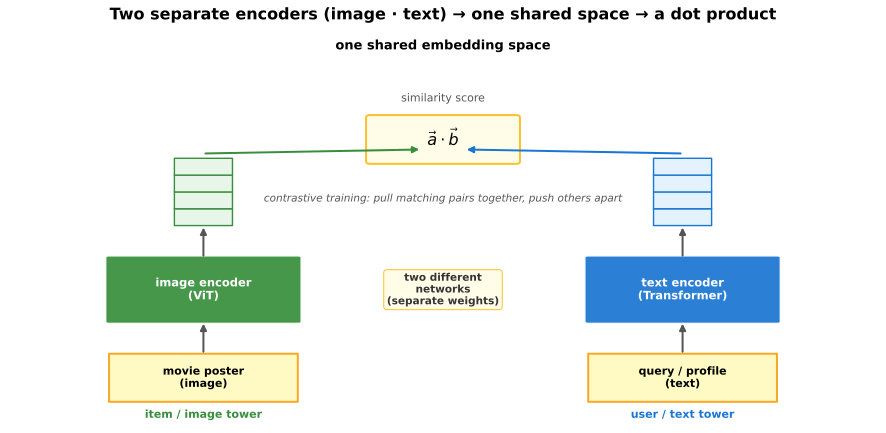

In [3]:
# The two-tower pattern: two encoders -> one shared space -> dot-product score (trained contrastively).
fig, ax = plt.subplots(figsize=(12.5, 6.2)); ax.axis('off')
ax.set_xlim(0, 12); ax.set_ylim(0, 10)

def tower(x, label, inp, enc, col):
    ax.add_patch(Rectangle((x-1.3, 0.6), 2.6, 1.2, facecolor='#fff9c4', edgecolor='#f9a825', lw=2))
    ax.text(x, 1.2, inp, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.add_patch(FancyBboxPatch((x-1.3, 2.6), 2.6, 1.6, boxstyle='round,pad=0.05',
                                facecolor=col, edgecolor='white', lw=2, alpha=0.92))
    ax.text(x, 3.4, enc, ha='center', va='center', fontsize=11.5, color='white', fontweight='bold')
    for j in range(4):                                   # output vector
        ax.add_patch(Rectangle((x-0.4+j*0.0, 5.1+j*0.0), 0, 0, facecolor='none'))
    for j in range(4):
        ax.add_patch(Rectangle((x-0.4, 5.0+j*0.42), 0.8, 0.42, facecolor='#e8f5e9' if col==GREEN else '#e3f2fd',
                               edgecolor=col, lw=1.4))
    ax.annotate('', xy=(x, 2.6), xytext=(x, 1.8), arrowprops=dict(arrowstyle='-|>', color='#555', lw=2))
    ax.annotate('', xy=(x, 5.0), xytext=(x, 4.2), arrowprops=dict(arrowstyle='-|>', color='#555', lw=2))
    ax.text(x, 0.2, label, ha='center', fontsize=11, fontweight='bold', color=col)

tower(2.7, 'item / image tower', 'movie poster\n(image)', 'image encoder\n(ViT)', GREEN)
tower(9.3, 'user / text tower', 'query / profile\n(text)', 'text encoder\n(Transformer)', BLUE)

# emphasise: in THIS (CLIP-style) case the two towers are genuinely different networks
ax.text(6.0, 3.4, 'two different\nnetworks\n(separate weights)', ha='center', va='center',
        fontsize=10.5, fontweight='bold', color='#333',
        bbox=dict(boxstyle='round', fc='#fffde7', ec='#fbc02d'))

# dot product node
ax.add_patch(FancyBboxPatch((5.0, 6.6), 2.0, 1.1, boxstyle='round,pad=0.06',
                            facecolor='#fffde7', edgecolor='#fbc02d', lw=2))
ax.text(6.0, 7.15, r'$\vec a \cdot \vec b$', ha='center', va='center', fontsize=16, fontweight='bold')
ax.text(6.0, 8.1, 'similarity score', ha='center', fontsize=11, color='#555')
for x0 in (2.7, 9.3):
    ax.annotate('', xy=(5.7 if x0 < 6 else 6.3, 6.9), xytext=(x0, 6.8),
                arrowprops=dict(arrowstyle='-|>', color=GREEN if x0 < 6 else BLUE, lw=2))
ax.text(6.0, 9.4, 'one shared embedding space', ha='center', fontsize=13, fontweight='bold')
ax.annotate('contrastive training: pull matching pairs together, push others apart',
            xy=(6, 5.6), ha='center', fontsize=10.5, color='#555', style='italic')
ax.set_title('Two separate encoders (image · text) → one shared space → a dot product', fontweight='bold')
plt.tight_layout(); plt.show()

> The weight-*shared* case counts too — **SBERT** is a *Siamese* tower (one encoder, two passes) — and even
> the **autoencoder** fits the same dot-product shape. Same shape every time.

## How a vision encoder works (1): image → patches

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- A **text** encoder splits a sentence into **word tokens**.
- A **vision** encoder (ViT) splits an image into a grid of **patches**; **each patch becomes one token** —
  the image's version of a word token.
- Each patch is flattened and **linearly projected** into a vector (its **token / patch embedding**) — just
  like a word vector.

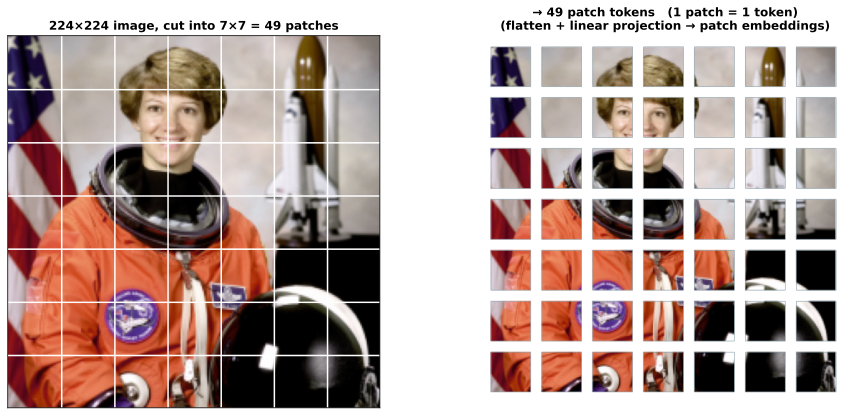

Each 32×32×3 patch is flattened to 3072 numbers, then projected to a d-dim vector — that vector is the token.


In [4]:
# Image -> a grid of patches -> a sequence of "patch tokens" (the input to a Vision Transformer).
img = resize(np.asarray(IMAGES[0]), (224, 224), anti_aliasing=True)   # the astronaut
ng = 7; P = 224 // ng                                                  # 7x7 = 49 patches of 32px
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 6.0))

# left: the image with a patch grid
axL.imshow(img)
for k in range(1, ng):
    axL.axhline(k * P, color='white', lw=1.5); axL.axvline(k * P, color='white', lw=1.5)
axL.set_title(f'224×224 image, cut into {ng}×{ng} = {ng*ng} patches', fontsize=12, fontweight='bold')
axL.set_xticks([]); axL.set_yticks([])

# right: the same patches, "exploded" into a sequence with small gaps
gap = 0.28
for r in range(ng):
    for c in range(ng):
        patch = img[r*P:(r+1)*P, c*P:(c+1)*P]
        x = c * (1 + gap); y = (ng - 1 - r) * (1 + gap)
        axR.imshow(patch, extent=[x, x + 1, y, y + 1])
        axR.add_patch(Rectangle((x, y), 1, 1, fill=False, edgecolor='#90a4ae', lw=0.6))
axR.set_xlim(-0.2, ng * (1 + gap)); axR.set_ylim(-0.4, ng * (1 + gap))
axR.set_aspect('equal'); axR.axis('off')
axR.set_title(f'→ {ng*ng} patch tokens   (1 patch = 1 token)\n(flatten + linear projection → patch embeddings)',
              fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('Each 32×32×3 patch is flattened to 3072 numbers, then projected to a d-dim vector — that vector is the token.')

> Our **clip-ViT-B/32** cuts a 224×224 image into 32×32 patches → a **7×7 = 49-token** sequence;
> each patch is flattened to 32·32·3 = **3072 numbers**, then **linearly projected** to a *d*-dim vector.
> (Bigger ViTs, e.g. B/16, use 16×16 patches → 14×14 = 196 tokens — same idea, finer grid.) Nothing about the
> pixels is hand-engineered — the projection is **learned**, exactly like S8's embedding matrix.

## How a vision encoder works (2): patches → transformer → one vector

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- Add **positional embeddings** — self-attention treats its inputs as an unordered set, so each patch is tagged with a learned position vector (otherwise the encoder couldn't tell top-left from bottom-right).
- Run the **same self-attention transformer** as BERT — every patch attends to every other.
- **Pool** the patch vectors (e.g. average them) → **one image vector**.

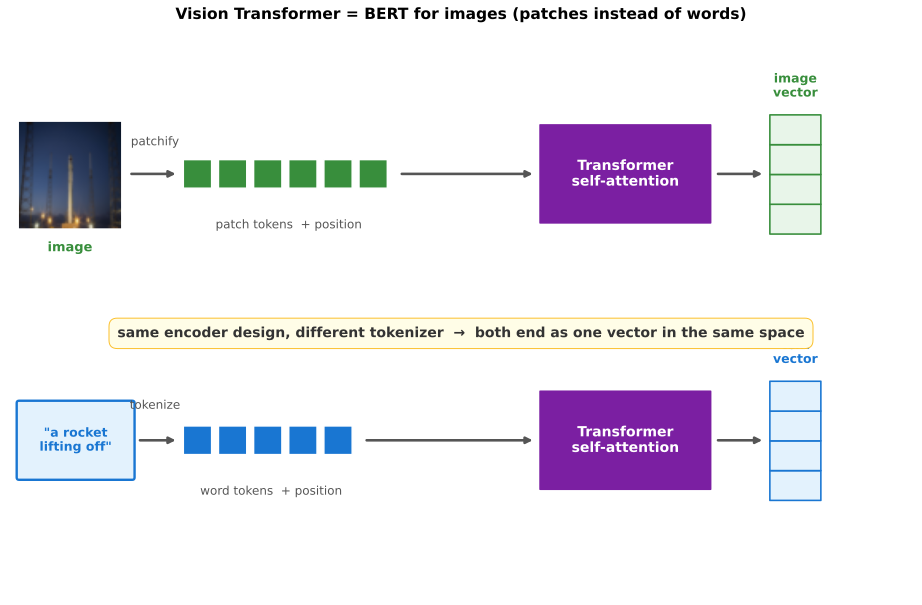

In [5]:
# ViT pipeline drawn as a schematic, with the parallel text encoder underneath (same transformer).
# Drawn large (tall figsize + big fonts) so labels stay readable on a projector.
fig, ax = plt.subplots(figsize=(13, 8.6)); ax.axis('off')
ax.set_xlim(0, 16); ax.set_ylim(0, 10)

def box(x, y, w, h, t, fc, ec, fs=14, fw='bold', tc='#222'):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.04', facecolor=fc, edgecolor=ec, lw=2.4))
    ax.text(x + w/2, y + h/2, t, ha='center', va='center', fontsize=fs, fontweight=fw, color=tc)
def arrow(x0, x1, y):
    ax.annotate('', xy=(x1, y), xytext=(x0, y), arrowprops=dict(arrowstyle='-|>', color='#555', lw=2.6))

def token_row(x, y, n, col):
    xs = x
    for _ in range(n):
        ax.add_patch(Rectangle((xs, y), 0.5, 0.5, facecolor=col, edgecolor='white', lw=1.5))
        xs += 0.62
    return xs

# --- vision row ---
yv = 6.8
img = resize(np.asarray(IMAGES[3]), (64, 64), anti_aliasing=True)     # rocket thumbnail
ax.imshow(img, extent=[0.2, 2.0, yv - 0.35, yv + 1.5], aspect='auto', zorder=3)
ax.text(1.1, yv - 0.75, 'image', ha='center', fontsize=13, fontweight='bold', color=GREEN)
arrow(2.15, 3.0, yv + 0.6)
ax.text(2.6, yv + 1.1, 'patchify', ha='center', fontsize=12, color='#555')
xend = token_row(3.1, yv + 0.35, 6, GREEN)
ax.text((3.1 + xend)/2, yv - 0.35, 'patch tokens  + position', ha='center', fontsize=12, color='#555')
arrow(xend + 0.1, 9.3, yv + 0.6)
box(9.4, yv - 0.25, 3.0, 1.7, 'Transformer\nself-attention', PURPLE, 'white', 14, 'bold', 'white')
arrow(12.5, 13.35, yv + 0.6)
for j in range(4):
    ax.add_patch(Rectangle((13.45, yv - 0.45 + j*0.52), 0.9, 0.52, facecolor='#e8f5e9', edgecolor=GREEN, lw=1.6))
ax.text(13.9, yv + 1.95, 'image\nvector', ha='center', fontsize=12.5, fontweight='bold', color=GREEN)

# --- text row (parallel) ---
yt = 2.1
box(0.2, yt, 2.0, 1.3, '"a rocket\nlifting off"', '#e3f2fd', BLUE, 12.5, 'bold', BLUE)
arrow(2.3, 3.0, yt + 0.65)
ax.text(2.6, yt + 1.2, 'tokenize', ha='center', fontsize=12, color='#555')
xend2 = token_row(3.1, yt + 0.4, 5, BLUE)
ax.text((3.1 + xend2)/2, yt - 0.3, 'word tokens  + position', ha='center', fontsize=12, color='#555')
arrow(xend2 + 0.1, 9.3, yt + 0.65)
box(9.4, yt - 0.2, 3.0, 1.7, 'Transformer\nself-attention', PURPLE, 'white', 14, 'bold', 'white')
arrow(12.5, 13.35, yt + 0.65)
for j in range(4):
    ax.add_patch(Rectangle((13.45, yt - 0.4 + j*0.52), 0.9, 0.52, facecolor='#e3f2fd', edgecolor=BLUE, lw=1.6))
ax.text(13.9, yt + 2.0, 'text\nvector', ha='center', fontsize=12.5, fontweight='bold', color=BLUE)

ax.annotate('same encoder design, different tokenizer  →  both end as one vector in the same space',
            xy=(8, 4.55), ha='center', fontsize=14, color='#333', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', fc='#fffde7', ec='#fbc02d'))
ax.set_title('Vision Transformer = BERT for images (patches instead of words)', fontsize=15.5, fontweight='bold')
plt.tight_layout(); plt.show()

> This is S9's BERT machinery with a different *tokenizer*: words → patches. Because both are the same
> transformer, "image → vector" and "text → vector" come out as **one vector of the same shape** — so the
> two *can* be trained into the **same space**. But how do you train a ViT in the first place? (next)

## How is a ViT trained? (the objective)

<small><span style="color:#1976d2"><b>Awareness</b></span> — appreciate the idea, don't memorize the internals.</small>

- **BERT** learns by **masked tokens** (fill the blank); **GPT** by **next-token** prediction. A ViT has a few options:
- **Supervised:** add a classifier head and predict the image's **label** (cat / dog / …) — the original ViT (2020).
- **MAE — the literal "BERT for images":** **hide ~70% of the patches and reconstruct them.** Self-supervised,
  no labels — masked-*token* prediction, where the tokens are image patches.
- **Contrastive (CLIP):** no labels, no reconstruction — train the image tower **against captions** so a
  picture lands next to its text. ← **this is the one we use** (next slide).

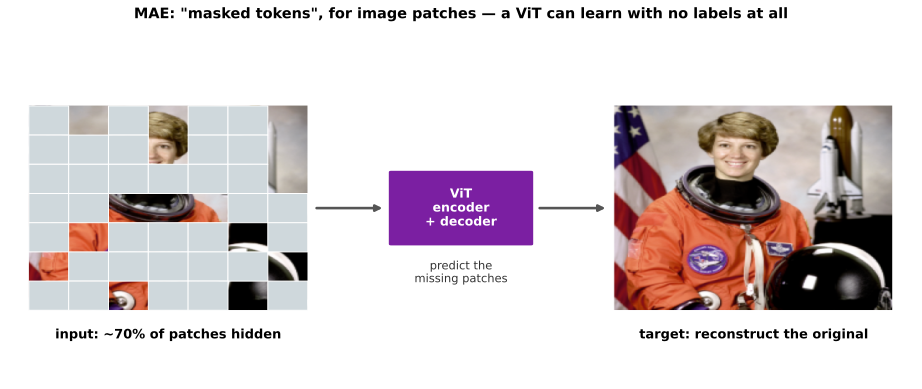

Other objectives: supervised (predict the label) and — what we use — contrastive against captions (CLIP, next).


In [6]:
# MAE / masked image modelling: hide most patches, reconstruct them -> the literal "BERT for images" objective.
# Single axes (deck convention) so the tight bbox stays clean.
src = resize(np.asarray(IMAGES[0]), (224, 224), anti_aliasing=True)   # astronaut
ng = 7
keep = np.random.default_rng(1).random((ng, ng)) > 0.70              # keep ~30%, hide ~70%
fig, ax = plt.subplots(figsize=(13, 5.6)); ax.axis('off')
ax.set_xlim(0, 13); ax.set_ylim(0, 7)
cell = 4.0 / ng

# left: masked input (grey over hidden patches)
ax.imshow(src, extent=[0.3, 4.3, 1.4, 5.4], aspect='auto', zorder=2)
for r in range(ng):
    for c in range(ng):
        if not keep[r, c]:
            ax.add_patch(Rectangle((0.3 + c*cell, 5.4 - (r+1)*cell), cell, cell,
                                   facecolor='#cfd8dc', edgecolor='white', lw=1, zorder=3))
ax.text(2.3, 0.85, 'input: ~70% of patches hidden', ha='center', fontsize=13, fontweight='bold')

# middle: the model + arrows (kept inside the axes)
ax.annotate('', xy=(5.4, 3.4), xytext=(4.4, 3.4), arrowprops=dict(arrowstyle='-|>', color='#555', lw=2.6))
ax.add_patch(FancyBboxPatch((5.5, 2.7), 2.0, 1.4, boxstyle='round,pad=0.05',
                            facecolor=PURPLE, edgecolor='white', lw=2))
ax.text(6.5, 3.4, 'ViT\nencoder\n+ decoder', ha='center', va='center', color='white', fontsize=12.5, fontweight='bold')
ax.annotate('', xy=(8.6, 3.4), xytext=(7.6, 3.4), arrowprops=dict(arrowstyle='-|>', color='#555', lw=2.6))
ax.text(6.5, 1.95, 'predict the\nmissing patches', ha='center', fontsize=11.5, color='#333')

# right: reconstruction target (the full image)
ax.imshow(src, extent=[8.7, 12.7, 1.4, 5.4], aspect='auto', zorder=2)
ax.text(10.7, 0.85, 'target: reconstruct the original', ha='center', fontsize=13, fontweight='bold')

ax.set_title('MAE: "masked tokens", for image patches — a ViT can learn with no labels at all',
             fontsize=14.5, fontweight='bold')
plt.tight_layout(); plt.show()
print('Other objectives: supervised (predict the label) and — what we use — contrastive against captions (CLIP, next).')

> Different objective, same backbone: however you train it, a ViT still turns an image into one vector.
> CLIP just trains that vector to **share a space with text**.

## Multimodality: images and text in ONE space (CLIP)

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- Train an **image tower (ViT)** and a **text tower** *together* so a picture lands right next to its **caption**.
- The payoff: **one shared space** — cosine now compares a **picture and a sentence directly**.
- So you can **write text and retrieve images** (or the reverse) — meaning matches *across modalities*, with no shared keywords.

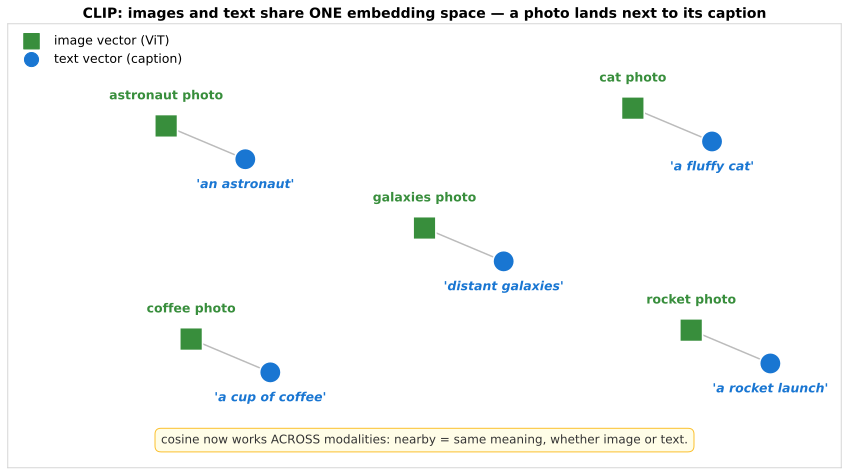

In [7]:
# Concept: CLIP maps images AND text into ONE space; each photo lands next to its caption.
fig, ax = plt.subplots(figsize=(12, 6.8))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
concepts = [('astronaut', "'an astronaut'",     1.9, 7.7),
            ('cat',       "'a fluffy cat'",      7.5, 8.1),
            ('rocket',    "'a rocket launch'",   8.2, 3.1),
            ('coffee',    "'a cup of coffee'",   2.2, 2.9),
            ('galaxies',  "'distant galaxies'",  5.0, 5.4)]
for name, cap, x, y in concepts:
    ax.scatter([x], [y], marker='s', s=520, color=GREEN, edgecolor='white', linewidth=1.6, zorder=3)
    ax.scatter([x + 0.95], [y - 0.75], marker='o', s=460, color=BLUE, edgecolor='white', linewidth=1.6, zorder=3)
    ax.plot([x, x + 0.95], [y, y - 0.75], color='#bbb', lw=1.5, zorder=1)
    ax.text(x, y + 0.6, name + ' photo', ha='center', fontsize=12.5, fontweight='bold', color=GREEN)
    ax.text(x + 0.95, y - 1.4, cap, ha='center', fontsize=12.5, fontweight='bold', color=BLUE, style='italic')
ax.scatter([], [], marker='s', s=240, color=GREEN, label='image vector (ViT)')
ax.scatter([], [], marker='o', s=200, color=BLUE, label='text vector (caption)')
ax.legend(loc='upper left', frameon=False, fontsize=12.5)
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_color('#ccc')
ax.text(5, 0.55, 'cosine now works ACROSS modalities: nearby = same meaning, whether image or text.',
        ha='center', fontsize=12, color='#333', bbox=dict(boxstyle='round,pad=0.5', fc='#fffde7', ec='#fbc02d'))
ax.set_title('CLIP: images and text share ONE embedding space — a photo lands next to its caption',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

> Same `SentenceTransformer.encode()` as S9 — now it encodes **images too**, into the same 512-d space. For
> movies, the image tower eats **posters**. (CLIP, 2021; **SigLIP / SigLIP-2** are the modern successors —
> *how* it's trained is the next slide.)

## How CLIP is trained: contrastive, cross-modal

<small><span style="color:#1976d2"><b>Awareness</b></span> — appreciate the idea, don't memorize the internals.</small>

- **Exactly the SBERT recipe from the recap** — but each positive pair is now an **(image, caption)**.
- The true pairs are the **diagonal** of the **N×N image–text cosine matrix**; push the diagonal up, the rest down.
- **CLIP** softmaxes each row & column (**InfoNCE**); **SigLIP** instead puts an independent **sigmoid** on
  *every cell* (each pair judged match / no-match on its own — no batch-wide normalization, small-batch-friendly).

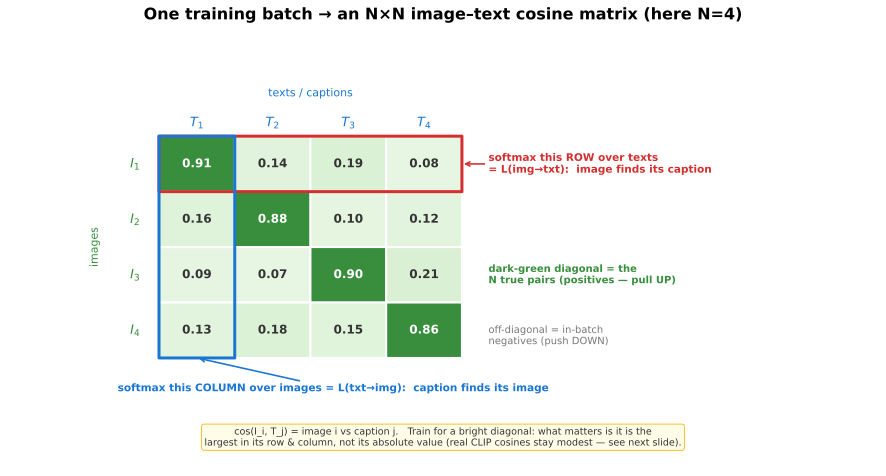

In [8]:
# Teaching schematic: ONE batch -> an N x N image-text cosine matrix; training drives a bright diagonal.
fig, ax = plt.subplots(figsize=(12.5, 6.8)); ax.axis('off')
ax.set_xlim(0, 11.5); ax.set_ylim(0, 8)
M = np.array([[0.91, 0.14, 0.19, 0.08],
              [0.16, 0.88, 0.10, 0.12],
              [0.09, 0.07, 0.90, 0.21],
              [0.13, 0.18, 0.15, 0.86]])
N, x0, ytop = 4, 2.0, 6.0
for r in range(N):
    for c in range(N):
        x, y = x0 + c, ytop - 1 - r
        diag = (r == c)
        fc = GREEN if diag else plt.cm.Greens(0.08 + 0.45 * M[r, c])
        ax.add_patch(Rectangle((x, y), 1, 1, facecolor=fc, edgecolor='white', lw=2))
        ax.text(x + 0.5, y + 0.5, f'{M[r, c]:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white' if diag else '#333')
for c in range(N):                                        # column = a text/caption
    ax.text(x0 + c + 0.5, ytop + 0.18, f'$T_{{{c+1}}}$', ha='center', fontsize=13, fontweight='bold', color=BLUE)
ax.text(x0 + N/2, ytop + 0.72, 'texts / captions', ha='center', fontsize=11, color=BLUE)
for r in range(N):                                        # row = an image
    ax.text(x0 - 0.25, ytop - 1 - r + 0.5, f'$I_{{{r+1}}}$', ha='right', va='center', fontsize=13, fontweight='bold', color=GREEN)
ax.text(x0 - 0.85, ytop - N/2, 'images', ha='center', va='center', rotation=90, fontsize=11, color=GREEN)
# a row -> image-to-text loss
ax.add_patch(Rectangle((x0, ytop - 1), N, 1, fill=False, edgecolor=RED, lw=3))
ax.annotate('softmax this ROW over texts\n= L(img→txt):  image finds its caption',
            xy=(x0 + N, ytop - 0.5), xytext=(x0 + N + 0.35, ytop - 0.5), va='center',
            fontsize=10.5, color=RED, fontweight='bold', arrowprops=dict(arrowstyle='->', color=RED, lw=1.6))
# a column -> text-to-image loss
ax.add_patch(Rectangle((x0, ytop - N), 1, N, fill=False, edgecolor=BLUE, lw=3))
ax.annotate('softmax this COLUMN over images = L(txt→img):  caption finds its image',
            xy=(x0 + 0.5, ytop - N), xytext=(x0 + N/2 + 0.3, 1.4), ha='center',
            fontsize=10.5, color=BLUE, fontweight='bold', arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.6))
# diagonal = positives, off-diagonal = in-batch negatives (dark-green diagonal is self-evident, no arrow)
ax.text(x0 + N + 0.35, 3.5, 'dark-green diagonal = the\nN true pairs (positives — pull UP)',
        fontsize=10, color=GREEN, fontweight='bold', va='center')
ax.text(x0 + N + 0.35, 2.4, 'off-diagonal = in-batch\nnegatives (push DOWN)', fontsize=10, color='#777', va='center')
ax.text(5.75, 0.42, 'cos(I_i, T_j) = image i vs caption j.   Train for a bright diagonal: what matters is it is the\n'
        'largest in its row & column, not its absolute value (real CLIP cosines stay modest — see next slide).',
        ha='center', fontsize=9.6, color='#333', bbox=dict(boxstyle='round', fc='#fffde7', ec='#fbc02d'))
ax.set_title('One training batch → an N×N image–text cosine matrix (here N=4)', fontweight='bold')
plt.tight_layout(); plt.show()

> Same matrix, same loss as the S9 SBERT recap — only the two sides changed: text↔text becomes **image↔text**.

## CLIP in action: a text query finds its image, live

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- The **same** model encodes the free-text queries and the photos; cosine ranks them.
- Read each **row**: the query's true image is the **brightest cell** (ringed) — retrieval with zero keyword overlap.
- Cosines are **absolute-low (~0.2–0.33)** — that is by design (CLIP's vectors all point into a **narrow region of the sphere**); what matters is the **row-winner**, not the magnitude.

In [9]:
# Cross-modal retrieval in a few lines: ONE model encodes BOTH images and text into one 512-d space.
from sentence_transformers import SentenceTransformer
from skimage import data
from PIL import Image

clip = SentenceTransformer('clip-ViT-B-32')            # the SAME model for images AND text

# six demo photos (skimage's bundled set) — stand-ins for movie posters
images  = [Image.fromarray(im).convert('RGB') for im in
           (data.astronaut(), data.chelsea(), data.coffee(),
            data.rocket(), data.hubble_deep_field(), data.camera())]
queries = ['an astronaut in space', 'a fluffy cat', 'a cup of coffee',
           'a rocket launch', 'a field of distant galaxies', 'a person with a camera']

iv = clip.encode(images,  normalize_embeddings=True)   # image vectors  (6 x 512)
tv = clip.encode(queries, normalize_embeddings=True)   # text  vectors  (6 x 512)
S  = tv @ iv.T                                          # cosine similarity: queries x images

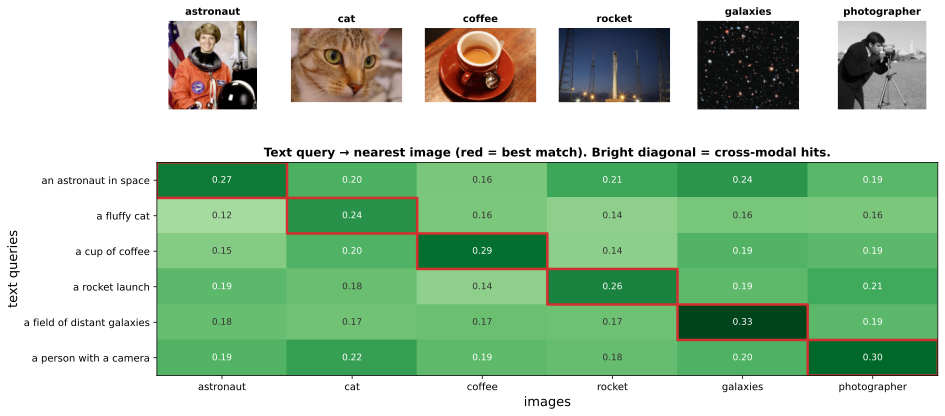

One model, two modalities, one space — every query retrieves its image with no keyword overlap.
Cosines look low (~0.2-0.33) by design — CLIP sharpens them with a temperature at train time; the diagonal being the row-max is the hit, not its absolute value.


In [10]:
fig = plt.figure(figsize=(14, 6.4))
gs = fig.add_gridspec(2, len(images), height_ratios=[1, 2.4], hspace=0.35)
# top: the image thumbnails
for j, (im, lab) in enumerate(zip(images, IMG_LABELS)):
    axi = fig.add_subplot(gs[0, j]); axi.imshow(im); axi.axis('off')
    axi.set_title(lab, fontsize=10, fontweight='bold')
# bottom: the cosine heatmap, brightest cell per row ringed
axH = fig.add_subplot(gs[1, :])
axH.imshow(S, cmap='Greens', vmin=0, vmax=float(S.max()), aspect='auto')
axH.set_xticks(range(len(IMG_LABELS))); axH.set_xticklabels(IMG_LABELS, fontsize=10)
axH.set_yticks(range(len(queries))); axH.set_yticklabels(queries, fontsize=10)
for r in range(S.shape[0]):
    for c in range(S.shape[1]):
        axH.text(c, r, f'{S[r,c]:.2f}', ha='center', va='center', fontsize=9,
                 color='white' if S[r, c] > 0.55 * S.max() else '#333')
    b = int(S[r].argmax())
    axH.add_patch(Rectangle((b - 0.5, r - 0.5), 1, 1, fill=False, edgecolor=RED, lw=2.5))
axH.set_xlabel('images'); axH.set_ylabel('text queries')
axH.set_title('Text query → nearest image (red = best match). Bright diagonal = cross-modal hits.',
              fontsize=12, fontweight='bold')
plt.show()
print('One model, two modalities, one space — every query retrieves its image with no keyword overlap.')
print('Cosines look low (~0.2-0.33) by design — CLIP sharpens them with a temperature at train time; '
      'the diagonal being the row-max is the hit, not its absolute value.')

## Fusing modalities: three encoders → one item vector

<small><span style="color:#1976d2"><b>Awareness</b></span> — appreciate the idea, don't memorize the internals.</small>

- A movie has three signals — plot **text**, **poster** image, rating **interactions** — each with its **own
  encoder**, giving three vectors that live in **different spaces and sizes**.
- **Concatenate → a small *fusion MLP* → one item vector** of dimension *d*. The *fusion MLP*
  (multi-layer perceptron — a couple of linear layers with a nonlinearity between) **learns** how much to
  trust each modality.
- That item vector is scored against the **user vector** by the same dot product — so **both towers must
  output the same _d_**.

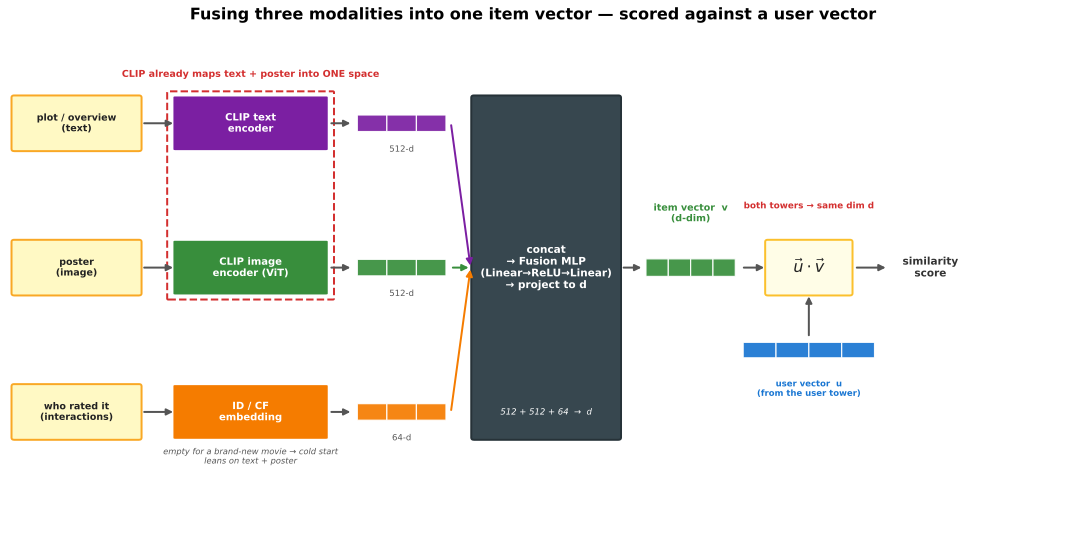

In [11]:
# Multimodal item tower: three encoders -> concat -> fusion MLP -> ONE item vector, scored vs the user tower.
fig, ax = plt.subplots(figsize=(15, 7.8)); ax.axis('off')
ax.set_xlim(0, 16); ax.set_ylim(0, 10)

def fbox(cx, cy, w, h, t, fc, ec, fs=10, tc='#222'):
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h, boxstyle='round,pad=0.04',
                                facecolor=fc, edgecolor=ec, lw=2))
    if t:
        ax.text(cx, cy, t, ha='center', va='center', fontsize=fs, fontweight='bold', color=tc)

def vec(cx, cy, col, n=3, cw=0.45, ch=0.32):
    x0 = cx - (n*cw)/2
    for j in range(n):
        ax.add_patch(Rectangle((x0 + j*cw, cy - ch/2), cw, ch, facecolor=col, edgecolor='white', lw=1.2, alpha=0.92))

def arr(x0, y0, x1, y1, col='#555'):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle='-|>', color=col, lw=2))

# ---- item tower: three modality branches (left -> right), converging into the fusion block ----
rows = [('plot / overview\n(text)',      'CLIP text\nencoder',       PURPLE, 8.1, '512-d'),
        ('poster\n(image)',              'CLIP image\nencoder (ViT)', GREEN,  5.3, '512-d'),
        ('who rated it\n(interactions)', 'ID / CF\nembedding',        ORANGE, 2.5, '64-d')]
for inp, enc, col, y, dim in rows:
    fbox(1.05, y, 1.9, 1.0, inp, '#fff9c4', '#f9a825', 9.5)
    fbox(3.7, y, 2.3, 1.0, enc, col, 'white', 10, 'white')
    vec(6.0, y, col)
    ax.text(6.0, y - 0.55, dim, ha='center', fontsize=8.5, color='#555')
    arr(2.05, y, 2.55, y)
    arr(4.9, y, 5.25, y)
    arr(6.75, y, 7.05, 5.3, col)                       # converge into the fusion block

# ---- fusion block ----
fbox(8.2, 5.3, 2.2, 6.6, 'concat\n→ Fusion MLP\n(Linear→ReLU→Linear)\n→ project to d',
     '#37474f', '#263238', 10.5, 'white')
ax.text(8.2, 2.45, '512 + 512 + 64  →  d', ha='center', fontsize=8.5, color='white', style='italic')

# ---- item vector v ----
vec(10.4, 5.3, GREEN, n=4, cw=0.34, ch=0.34)
ax.text(10.4, 6.2, 'item vector  v\n(d-dim)', ha='center', fontsize=9.5, fontweight='bold', color=GREEN)
arr(9.35, 5.3, 9.68, 5.3)

# ---- dot-product node + score ----
fbox(12.2, 5.3, 1.25, 1.0, r'$\vec u \cdot \vec v$', '#fffde7', '#fbc02d', 16)
arr(11.18, 5.3, 11.55, 5.3)
arr(12.9, 5.3, 13.4, 5.3)
ax.text(14.05, 5.3, 'similarity\nscore', ha='center', va='center', fontsize=10.5, fontweight='bold', color='#333')
ax.text(12.2, 6.45, 'both towers → same dim d', ha='center', fontsize=8.8, color=RED, fontweight='bold')

# ---- user side: a faint user vector feeds the dot node from below (the full user tower is the Core slide) ----
vec(12.2, 3.7, BLUE, n=4, cw=0.5, ch=0.3)
ax.text(12.2, 2.95, 'user vector  u\n(from the user tower)', ha='center', va='center',
        fontsize=8.5, fontweight='bold', color=BLUE)
arr(12.2, 3.95, 12.2, 4.78)

# ---- CLIP shared-space callout (dashed box around the two CLIP encoders) ----
ax.add_patch(FancyBboxPatch((2.45, 4.7), 2.5, 4.0, boxstyle='round,pad=0.02',
                            fill=False, edgecolor=RED, lw=2, linestyle='--'))
ax.text(3.7, 9.0, 'CLIP already maps text + poster into ONE space',
        ha='center', fontsize=9.5, color=RED, fontweight='bold')

# ---- cold-start note ----
ax.text(3.7, 1.5, 'empty for a brand-new movie → cold start\nleans on text + poster',
        ha='center', fontsize=8.3, color='#555', style='italic')

ax.set_title('Fusing three modalities into one item vector — scored against a user vector', fontweight='bold')
plt.tight_layout(); plt.show()

> Encode **text *and* poster with CLIP** and they already share one space; the **interaction**
> branch is a separate learned table — and is **empty for a brand-new movie**, which is exactly why text +
> poster carry **cold-start**.

## Putting it in the pipeline

<small><span style="color:#388e3c"><b>Core</b></span> — the unifying idea of the whole arc.</small>

- Every tower emits a vector; the **vector database (ChromaDB) doesn't care about the modality** — text,
  poster and ratings all become rows in the same index.
- A movie can be **one fused item vector** (plot text + poster + interactions).
- So which representation actually recommends best? **Time to measure → Part 2: evaluation.**

> The big win of the embedding view: once everything is a vector, one retrieval engine serves
> content-based, collaborative and multimodal recommenders alike — and one evaluation harness scores them
> head-to-head.

In [12]:
# Part 2 — evaluation harness: leave-one-out + sampled negatives, four methods. ~30s (models cached).
import pandas as pd
from sentence_transformers import SentenceTransformer
from surprise import SVD, Dataset, Reader

_rat = pd.read_csv('ml-latest-small/ratings.csv').sort_values('timestamp')
_mov = pd.read_csv('ml-latest-small/movies.csv')
EV_REL, EV_K, EV_NNEG = 4.0, 10, 100
_rng = np.random.default_rng(42)

# temporal leave-one-out: hold out each user's MOST RECENT liked (>=4) movie
_held, _prof, _seen = {}, {}, {}
for u, g in _rat.groupby('userId'):
    _seen[u] = set(g.movieId)
    pos = g[g.rating >= EV_REL]
    if len(pos) < 6:
        continue
    _held[u] = pos.movieId.iloc[-1]; _prof[u] = pos.movieId.iloc[:-1].tolist()
EV_USERS = sorted(_held)
_all = _mov.movieId.values; _mi = {m: i for i, m in enumerate(_all)}

# item features: genre one-hot (L7) + SBERT text embedding (L9)
_gs = sorted({x for gg in _mov.genres for x in gg.split('|')})
_G = np.zeros((len(_all), len(_gs)))
for _, r in _mov.iterrows():
    for x in r.genres.split('|'):
        _G[_mi[r.movieId], _gs.index(x)] = 1
_G /= (np.linalg.norm(_G, axis=1, keepdims=True) + 1e-9)
_sb = SentenceTransformer('all-MiniLM-L6-v2')
_T = _sb.encode([f"{r.title}. Genres: {r.genres.replace('|', ', ')}." for _, r in _mov.iterrows()],
                normalize_embeddings=True, show_progress_bar=False)
_pop = _rat.groupby('movieId').size().reindex(_all).fillna(0).values

# collaborative SVD (L8) trained WITHOUT the held-out positives
_ho = set((u, _held[u]) for u in EV_USERS)
_tr = _rat[~_rat[['userId', 'movieId']].apply(tuple, axis=1).isin(_ho)]
_ts = Dataset.load_from_df(_tr[['userId', 'movieId', 'rating']],
                           Reader(rating_scale=(0.5, 5))).build_full_trainset()
_svd = SVD(n_factors=50, n_epochs=20, random_state=42); _svd.fit(_ts); _mu = _ts.global_mean
def _svd_score(u, cands):
    out = np.full(len(cands), _mu)
    try:
        pu, bu = _svd.pu[_ts.to_inner_uid(u)], _svd.bu[_ts.to_inner_uid(u)]
    except Exception:
        pu, bu = None, 0.0
    for j, m in enumerate(cands):
        try:
            ii = _ts.to_inner_iid(m)
            out[j] = _mu + bu + _svd.bi[ii] + (pu @ _svd.qi[ii] if pu is not None else 0)
        except Exception:
            out[j] = -1e9                 # item with no interaction history -> CF cannot place it
    return out
def _pf(u, M):
    return M[[_mi[m] for m in _prof[u]]].mean(0)

EV_METHODS = ['Popularity', 'Content (genre)', 'Text emb (SBERT)', 'SVD (collab)']
EV_COLORS  = ['#90a4ae', GREEN, PURPLE, BLUE]
_score = {
    'Popularity':       lambda u, c: _pop[[_mi[m] for m in c]],
    'Content (genre)':  lambda u, c: _G[[_mi[m] for m in c]] @ _pf(u, _G),
    'Text emb (SBERT)': lambda u, c: _T[[_mi[m] for m in c]] @ _pf(u, _T),
    'SVD (collab)':     _svd_score,
}
def _eval(fn, only=None):
    hr = ndcg = 0.0; n = 0
    for u in EV_USERS:
        pos = _held[u]
        if only is not None and pos not in only:
            continue
        unseen = np.setdiff1d(_all, list(_seen[u]))
        negs = _rng.choice(unseen, size=min(EV_NNEG, len(unseen)), replace=False)
        cands = np.concatenate([[pos], negs]); sc = fn(u, cands)
        rank = int((sc > sc[0]).sum())              # candidates that beat the held-out positive
        if rank < EV_K:
            hr += 1; ndcg += 1 / np.log2(rank + 2)
        n += 1
    return hr / n, ndcg / n, n

_cnt = _rat.groupby('movieId').size()
EV_COLD = set(m for m in (_held[u] for u in EV_USERS) if _cnt.get(m, 0) <= 5)
ev_warm = {m: _eval(_score[m])[:2] for m in EV_METHODS}     # (Recall@k, NDCG@k)
ev_cold = {m: _eval(_score[m], only=EV_COLD)[0] for m in EV_METHODS}
EV_NCOLD = len(EV_COLD)
print('warm Recall@%d:' % EV_K, {m: round(v[0], 3) for m, v in ev_warm.items()})
print('cold Recall@%d:' % EV_K, {m: round(v, 3) for m, v in ev_cold.items()}, '| cold users:', EV_NCOLD)

warm Recall@10: {'Popularity': 0.658, 'Content (genre)': 0.262, 'Text emb (SBERT)': 0.357, 'SVD (collab)': 0.427}
cold Recall@10: {'Popularity': 0.0, 'Content (genre)': 0.237, 'Text emb (SBERT)': 0.22, 'SVD (collab)': 0.051} | cold users: 59


## Part 2 — Evaluating retrieval: where's the ground truth?

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- **The embedding *is* the ranking:** score every candidate by **cosine similarity** to the user's profile, sort, take the top *k*. Content, SVD, text and multimodal all produce this *same kind* of ranking.
- **The ratings give the labels — *leave-one-out*:** hide each user's most-recent liked movie, then check whether the method retrieves it again (exactly how → next slide).
- **Two ranking metrics** (here *k* = 10; a **hit** = the hidden movie reaches the top *k*):
  - **Recall@k** — *did the hidden movie make the top k at all?* With a single held-out item this is just the **hit-rate**: 1 if it lands in the top *k*, else 0.
  - **[NDCG@k](https://en.wikipedia.org/wiki/Discounted_cumulative_gain)** — *and how near the top did it land?* a hit higher up is worth more, rescaled so a perfect ranking = 1 (rank 1 → 1.0, rank 3 → 0.5).

<small>Formulas, for reference — &nbsp; **Recall@k** = |relevant ∩ top-k| / |relevant| &nbsp;·&nbsp; **NDCG@k** = DCG@k / IDCG@k, &nbsp;with DCG@k = Σ<sub>i≤k</sub> rel<sub>i</sub> / log<sub>2</sub>(i+1) &nbsp;and IDCG = the best-possible DCG (the term that rescales the score into [0, 1]).</small>

> Two metrics because they ask different things: **Recall** = *did we find it*, **NDCG** = *did we rank it near the top* — a method can win one and lose the other. The next slides run **one identical test** on every method, so the four scores are directly comparable.

## How one test works — one hidden movie vs. 100 random

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- **One trial per user:** hide their **most-recent liked movie** (the *answer*), mix it into **100 random unseen movies** → **101 candidates**; **score each against the user vector**, sort, look at the **top 10**.
- **Every method is the same dot product** — they differ *only* in **how the user vector is built**:
  - **Content (L7) · Text (L9):** the **average** of the user's *other* liked-movie vectors.
  - **SVD (L8):** the **learned** user factor $p_u$ (fit from ratings, no features).
  - **Popularity:** **none** — it ignores the user and ranks everyone by rating count (the dumb baseline).
- A **hit** = the hidden movie lands in the top 10; **Recall@10** averages hits over users, **NDCG@10** also rewards a *higher* rank.

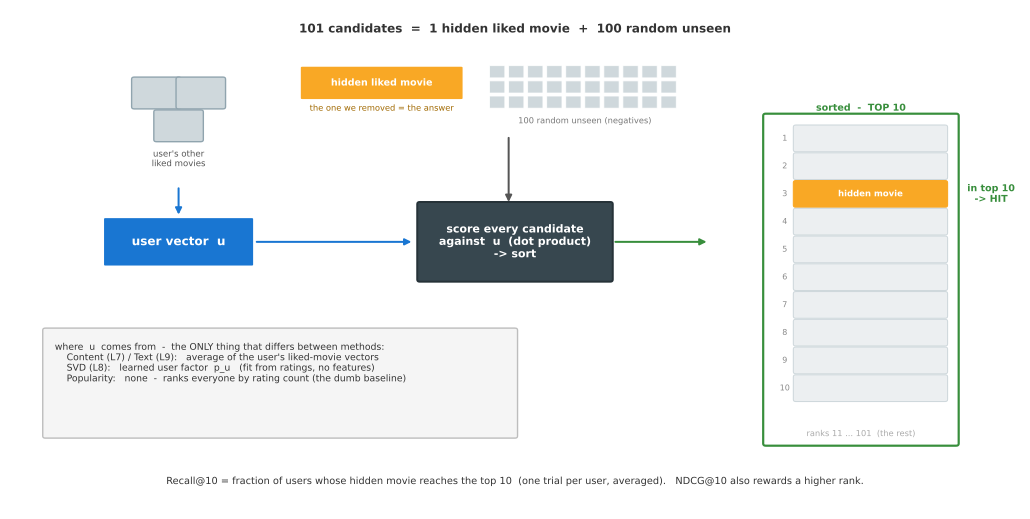

In [13]:
# How one test works: leave-one-out + sampled negatives. One user, 101 candidates -> does the hidden like reach top-10?
fig, ax = plt.subplots(figsize=(14.5, 7.4)); ax.axis('off')
ax.set_xlim(0, 16); ax.set_ylim(0, 10)
GOLD = '#f9a825'

def fbox(cx, cy, w, h, t, fc, ec, fs=10, tc='#222', lw=2.0):
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h, boxstyle='round,pad=0.04',
                                facecolor=fc, edgecolor=ec, lw=lw))
    if t:
        ax.text(cx, cy, t, ha='center', va='center', fontsize=fs, fontweight='bold', color=tc)

def arr(x0, y0, x1, y1, col='#555', lw=2.0):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle='-|>', color=col, lw=lw))

# ---- candidate pool (top centre): 1 hidden + 100 random ----
ax.text(8.0, 9.5, '101 candidates  =  1 hidden liked movie  +  100 random unseen', ha='center',
        fontsize=12, fontweight='bold', color='#333')
fbox(5.9, 8.5, 2.5, 0.6, 'hidden liked movie', GOLD, 'white', 9.5, 'white')
ax.text(5.9, 7.95, 'the one we removed = the answer', ha='center', fontsize=8.3, color='#a06800')
for r in range(3):
    for c in range(10):
        ax.add_patch(Rectangle((7.6 + c*0.3, 8.0 + r*0.3), 0.24, 0.24,
                               facecolor='#cfd8dc', edgecolor='white', lw=0.7))
ax.text(9.1, 7.7, '100 random unseen (negatives)', ha='center', fontsize=8.3, color='#777')
arr(7.9, 7.45, 7.9, 6.1)

# ---- user vector (left) ----
fbox(2.35, 8.3, 0.7, 0.55, '', '#cfd8dc', '#90a4ae', lw=1.4)
fbox(3.05, 8.3, 0.7, 0.55, '', '#cfd8dc', '#90a4ae', lw=1.4)
fbox(2.70, 7.65, 0.7, 0.55, '', '#cfd8dc', '#90a4ae', lw=1.4)
ax.text(2.7, 6.85, "user's other\nliked movies", ha='center', fontsize=8.6, color='#555')
arr(2.7, 6.45, 2.7, 5.85, BLUE)
fbox(2.7, 5.35, 2.3, 0.9, 'user vector  u', BLUE, 'white', 12, 'white')
arr(3.9, 5.35, 6.4, 5.35, BLUE)

# ---- scoring engine (centre): both inputs meet here ----
fbox(8.0, 5.35, 3.0, 1.5, 'score every candidate\nagainst  u  (dot product)\n-> sort', '#37474f', '#263238', 11, 'white')
arr(9.55, 5.35, 11.05, 5.35, GREEN)

# ---- sorted top-10 window (right) ----
wcx = 13.45
fbox(wcx, 4.6, 3.0, 6.5, '', '#ffffff', GREEN, lw=2.2)
ax.text(wcx, 7.95, 'sorted  -  TOP 10', ha='center', fontsize=9.5, fontweight='bold', color=GREEN)
for i in range(10):
    y = 7.4 - i*0.55
    hit = (i == 2)
    fbox(wcx + 0.15, y, 2.35, 0.45, '', GOLD if hit else '#eceff1', '#f9a825' if hit else '#cfd8dc', lw=1.1)
    ax.text(wcx - 1.2, y, str(i + 1), ha='center', va='center', fontsize=8, color='#888')
    if hit:
        ax.text(wcx + 0.15, y, 'hidden movie', ha='center', va='center', fontsize=8.5, fontweight='bold', color='white')
ax.text(wcx, 1.5, 'ranks 11 ... 101  (the rest)', ha='center', fontsize=8.3, color='#aaa')
hy = 7.4 - 2*0.55
ax.text(wcx + 2.05, hy, 'in top 10\n-> HIT', ha='center', va='center', fontsize=9.5, fontweight='bold', color=GREEN)

# ---- where u comes from (bottom-left note) ----
fbox(4.3, 2.55, 7.4, 2.1, '', '#f5f5f5', '#bdbdbd', lw=1.4)
note = ("where  u  comes from  -  the ONLY thing that differs between methods:\n"
        "    Content (L7) / Text (L9):   average of the user's liked-movie vectors\n"
        "    SVD (L8):   learned user factor  p_u   (fit from ratings, no features)\n"
        "    Popularity:   none  -  ranks everyone by rating count (the dumb baseline)")
ax.text(0.75, 3.35, note, ha='left', va='top', fontsize=9.3, color='#333')

# ---- bottom caption ----
ax.text(8.0, 0.55,
        'Recall@10 = fraction of users whose hidden movie reaches the top 10  (one trial per user, averaged).   '
        'NDCG@10 also rewards a higher rank.', ha='center', fontsize=9.8, color='#333')
plt.tight_layout(); plt.show()

> One yardstick for all four. *Two more methods (autoencoder, fusion MLP) need a **trained** network — next slide — then the leaderboard, where the dumbest method wins anyway.*

## Two methods we left out — where *their* user vector comes from

<small><span style="color:#1976d2"><b>Awareness</b></span> — appreciate the idea, don't memorize the internals.</small>

- The four methods on the leaderboard build the user vector **cheaply, with no training** — an *average* of liked-movie vectors (content, text), a *learned factor* read straight from the rating matrix (SVD), or *nothing at all* (popularity).
- **Two more methods fit the exact same dot product**, but their user vector is the **output of a trained neural network** — so we'd need fitted weights to score them:
  - **Autoencoder (S8 / S9):** the user vector is the **learned decoder row $V_u$** (the movie side is the *computed* bottleneck $h_i$); the score is $h_i \cdot V_u$.
  - **Fusion MLP / two-tower (today):** the user vector is the **output of a separate, learned user tower** (the item side is the fused multimodal vector).
- We have **no trained weights** for these on MovieLens, so they **sit out of our leaderboard** — but they'd plug into the *exact same* hidden-movie test.

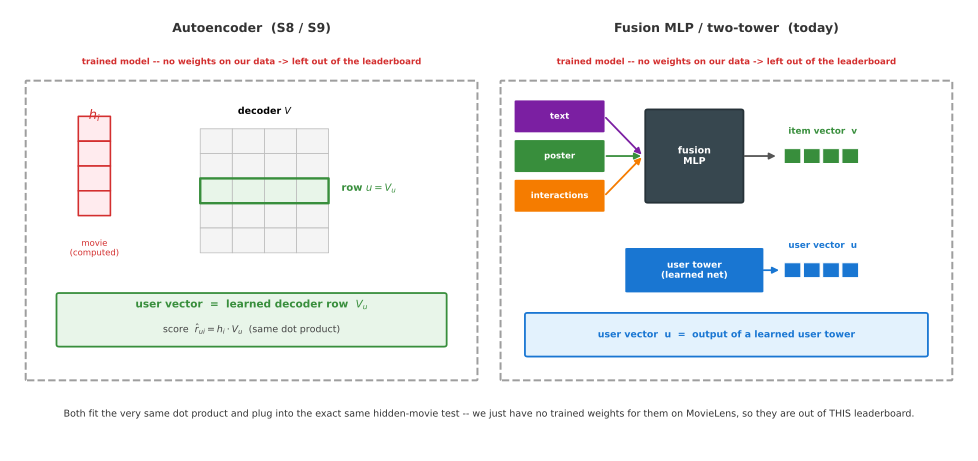

In [14]:
# Two more methods fit the SAME dot product, but their user vector is the output of a TRAINED network --
# we have no such weights fitted on MovieLens, so they sit out of the leaderboard.
fig, ax = plt.subplots(figsize=(14.5, 6.6)); ax.axis('off')
ax.set_xlim(0, 15); ax.set_ylim(0, 9)
RED2 = '#d32f2f'

def box(cx, cy, w, h, t, fc, ec, fs=10, tc='#222', lw=1.8):
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h, boxstyle='round,pad=0.04',
                                facecolor=fc, edgecolor=ec, lw=lw))
    if t:
        ax.text(cx, cy, t, ha='center', va='center', fontsize=fs, fontweight='bold', color=tc)

def arr(x0, y0, x1, y1, col='#666', lw=1.8):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle='-|>', color=col, lw=lw))

# ---- two dashed (= excluded) panels ----
ax.add_patch(FancyBboxPatch((0.3, 1.5), 7.0, 6.0, boxstyle='round,pad=0.02',
                            fill=False, edgecolor='#9e9e9e', lw=2, linestyle='--'))
ax.add_patch(FancyBboxPatch((7.7, 1.5), 7.0, 6.0, boxstyle='round,pad=0.02',
                            fill=False, edgecolor='#9e9e9e', lw=2, linestyle='--'))
ax.text(3.8, 8.5, 'Autoencoder  (S8 / S9)', ha='center', fontsize=12.5, fontweight='bold', color='#333')
ax.text(11.2, 8.5, 'Fusion MLP / two-tower  (today)', ha='center', fontsize=12.5, fontweight='bold', color='#333')
for cx in (3.8, 11.2):
    ax.text(cx, 7.85, 'trained model -- no weights on our data -> left out of the leaderboard',
            ha='center', fontsize=8.6, color=RED2, fontweight='bold')

# ===== LEFT: Autoencoder -- user vector = learned decoder row V_u =====
hx, hy = 1.1, 6.3
for j in range(4):
    ax.add_patch(Rectangle((hx, hy - j*0.5), 0.5, 0.5, facecolor='#ffebee', edgecolor=RED2, lw=1.6))
ax.text(hx + 0.25, hy + 0.45, r'$h_i$', ha='center', color=RED2, fontsize=13, fontweight='bold')
ax.text(hx + 0.25, hy - 4*0.5 - 0.3, 'movie\n(computed)', ha='center', color=RED2, fontsize=8.5)
vx, vy, rows, cols, uhi = 3.0, 6.55, 5, 4, 2
for r in range(rows):
    for c in range(cols):
        fc = '#e8f5e9' if r == uhi else '#f4f4f4'
        ax.add_patch(Rectangle((vx + c*0.5, vy - (r+1)*0.5), 0.5, 0.5, facecolor=fc, edgecolor='#bbb', lw=0.8))
ax.add_patch(Rectangle((vx, vy - (uhi+1)*0.5), cols*0.5, 0.5, fill=False, ec=GREEN, lw=2.4))
ax.text(vx + cols*0.5/2, vy + 0.3, r'decoder $V$', ha='center', fontsize=9.5, fontweight='bold')
ax.text(vx + cols*0.5 + 0.2, vy - (uhi+0.5)*0.5, r'row $u = V_u$', ha='left', color=GREEN, fontsize=10, fontweight='bold')
box(3.8, 2.7, 6.0, 1.0, '', '#e8f5e9', GREEN, lw=1.8)
ax.text(3.8, 2.95, 'user vector  =  learned decoder row  $V_u$', ha='center', fontsize=10.5, fontweight='bold', color=GREEN)
ax.text(3.8, 2.45, r'score  $\hat r_{ui} = h_i \cdot V_u$  (same dot product)', ha='center', fontsize=9.5, color='#444')

# ===== RIGHT: Fusion MLP -- user vector = output of a learned user tower =====
mods = [('text', PURPLE, 6.8), ('poster', GREEN, 6.0), ('interactions', ORANGE, 5.2)]
for t, col, y in mods:
    box(8.6, y, 1.35, 0.6, t, col, 'white', 8.5, 'white')
    arr(9.3, y, 9.9, 6.0, col)
box(10.7, 6.0, 1.45, 1.8, 'fusion\nMLP', '#37474f', '#263238', 9.5, 'white')
arr(11.45, 6.0, 12.0, 6.0, '#555')
for j in range(4):
    ax.add_patch(Rectangle((12.1 + j*0.3, 5.85), 0.26, 0.3, facecolor=GREEN, edgecolor='white', lw=1))
ax.text(12.7, 6.45, 'item vector  v', ha='center', fontsize=8.8, fontweight='bold', color=GREEN)
box(10.7, 3.7, 2.1, 0.85, 'user tower\n(learned net)', BLUE, 'white', 9, 'white')
arr(11.75, 3.7, 12.05, 3.7, BLUE)
for j in range(4):
    ax.add_patch(Rectangle((12.1 + j*0.3, 3.55), 0.26, 0.3, facecolor=BLUE, edgecolor='white', lw=1))
ax.text(12.7, 4.15, 'user vector  u', ha='center', fontsize=8.8, fontweight='bold', color=BLUE)
box(11.2, 2.4, 6.2, 0.8, 'user vector  u  =  output of a learned user tower', '#e3f2fd', BLUE, 9.4, BLUE, lw=1.8)

# ---- bottom caption ----
ax.text(7.5, 0.75,
        'Both fit the very same dot product and plug into the exact same hidden-movie test -- we just have no '
        'trained weights for them on MovieLens, so they are out of THIS leaderboard.',
        ha='center', fontsize=9.5, color='#333')
plt.tight_layout(); plt.show()

> Same dot product every time — only the *source* of the two vectors changes. Now the four methods we *can* score go head-to-head on the leaderboard.

## The leaderboard — and a trap

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- **Same task as the last slide, four rankers.** Each method sorts the 101 candidates (the **1 hidden liked
  movie + 100 random ones**); we check whether the hidden movie reaches the **top 10**.
- The four methods:
  - **Popularity** — rank by a movie's **total number of ratings** (most-rated first). The *same list for
    everyone* — **no personalization** (our dumb baseline).
  - **Content (L7)** · **Text (L9)** · **SVD (L8)** — the personalized methods from earlier sessions.
- **The trap:** the dumbest method — **popularity — wins the raw Recall@10** (chart).

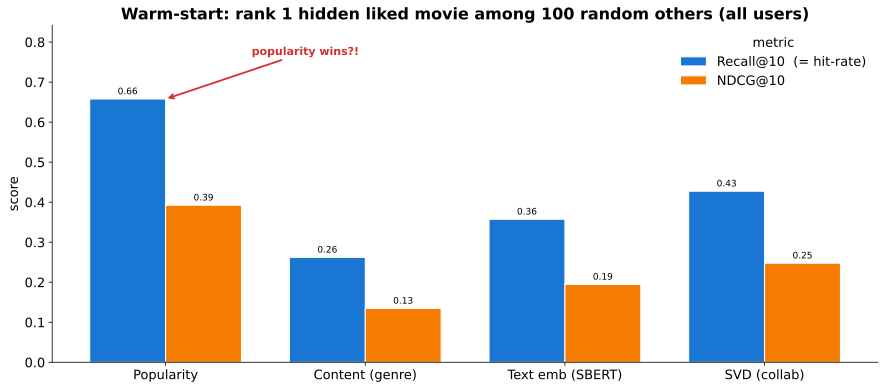

In [15]:
# Warm-start leaderboard: 4 methods on the x-axis, 2 bars each coloured BY METRIC (so the legend matches).
fig, ax = plt.subplots(figsize=(12.5, 5.6))
x = np.arange(len(EV_METHODS)); w = 0.38
rec = [ev_warm[m][0] for m in EV_METHODS]; ndg = [ev_warm[m][1] for m in EV_METHODS]
b1 = ax.bar(x - w/2, rec, w, label=f'Recall@{EV_K}  (= hit-rate)', color=BLUE, edgecolor='white')
b2 = ax.bar(x + w/2, ndg, w, label=f'NDCG@{EV_K}', color=ORANGE, edgecolor='white')
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012, f'{b.get_height():.2f}',
            ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(EV_METHODS); ax.set_ylim(0, max(rec) * 1.28)
ax.set_ylabel('score'); ax.legend(loc='upper right', frameon=False, title='metric')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(f'Warm-start: rank 1 hidden liked movie among {EV_NNEG} random others (all users)', fontweight='bold')
ax.annotate('popularity wins?!', xy=(0, rec[0]), xytext=(0.7, rec[0] + 0.11),
            fontsize=11, color=RED, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.8))
plt.tight_layout(); plt.show()

> A held-out *liked* movie is usually itself popular, so against random negatives the popularity baseline
> ranks it high — so **sampled-negative metrics flatter popularity**, and sampled scores can even reorder
> which method "wins" versus a full-catalogue ranking. **Best offline number ≠ best system.** Personalization
> earns its keep on diversity, the long tail, and — next slide — **cold-start**.

<small>Refs — Cremonesi, Koren & Turrin, *Performance of Recommender Algorithms on Top-N Recommendation Tasks*, RecSys 2010 ([doi.org/10.1145/1864708.1864721](https://doi.org/10.1145/1864708.1864721)) · Krichene & Rendle, *On Sampled Metrics for Item Recommendation*, KDD 2020 ([research.google](https://research.google/pubs/on-sampled-metrics-for-item-recommendation/)).</small>

## Cold-start: the real test

<small><span style="color:#388e3c"><b>Core</b></span> — be able to explain this.</small>

- **Re-run the exact same test**, but only on the **sparse items (≤5 ratings)** — the new-release case.
- **Popularity and collaborative SVD collapse** (no ratings to lean on); **content & text embeddings hold up**
  (they place the item from its *features*, not its history). Same four methods, warm vs cold.

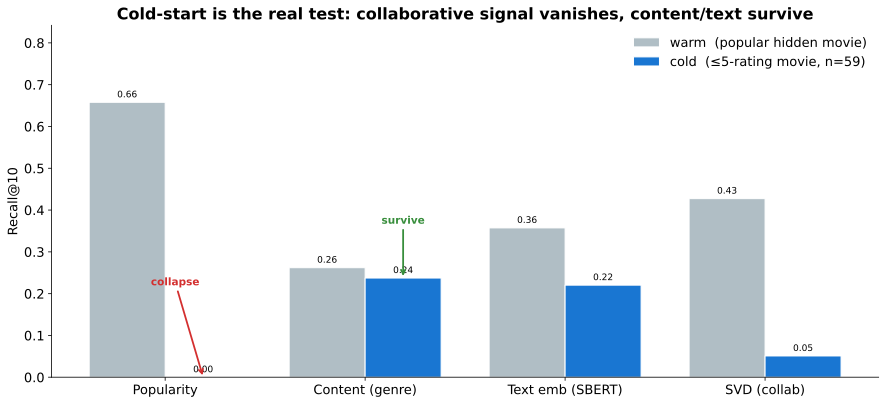

In [16]:
# The real test: warm vs COLD-start Recall@10. Collaborative methods collapse; content/text survive.
fig, ax = plt.subplots(figsize=(12.5, 5.8))
x = np.arange(len(EV_METHODS)); w = 0.38
warm = [ev_warm[m][0] for m in EV_METHODS]; cold = [ev_cold[m] for m in EV_METHODS]
ax.bar(x - w/2, warm, w, label='warm  (popular hidden movie)', color='#b0bec5', edgecolor='white')
ax.bar(x + w/2, cold, w, label=f'cold  (≤5-rating movie, n={EV_NCOLD})', color=BLUE, edgecolor='white')
for i, (wv, cv) in enumerate(zip(warm, cold)):
    ax.text(i - w/2, wv + 0.012, f'{wv:.2f}', ha='center', fontsize=9)
    ax.text(i + w/2, cv + 0.012, f'{cv:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(EV_METHODS); ax.set_ylabel(f'Recall@{EV_K}')
ax.set_ylim(0, max(warm) * 1.28); ax.legend(loc='upper right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Cold-start is the real test: collaborative signal vanishes, content/text survive',
             fontweight='bold')
ax.annotate('collapse', xy=(0 + w/2, cold[0]), xytext=(0.05, 0.22), ha='center', color=RED,
            fontsize=10.5, fontweight='bold', arrowprops=dict(arrowstyle='->', color=RED, lw=1.8))
ax.annotate('survive', xy=(1 + w/2, cold[1]), xytext=(1 + w/2, cold[1] + 0.13), ha='center',
            color=GREEN, fontsize=10.5, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.8))
plt.tight_layout(); plt.show()

> Collaborative signal needs a *substantial* interaction history; with ≤5 ratings the learned item factor is
> missing or far too noisy to rank — so SVD collapses. A **feature-based embedding** (genres, text — and, with
> posters, **images**) still places the item from its content alone. This is the payoff of the whole arc:
> **content embeddings are what make cold-start tractable** — and exactly why we built the multimodal image tower.

## Evaluating *your* project — *you* supply the ground truth

<small><span style="color:#1976d2"><b>Awareness</b></span> — appreciate the idea, don't memorize the internals.</small>

- For your **final project** you'll evaluate your *own* retrieval system. Our MovieLens eval borrowed labels
  from **user behavior** (we hid a rating) — but your dataset may have **no user log at all**, just items
  (repos, papers, products…).
- So **you** must supply the **relevance judgments** — for each **query**, which items count as correct
  answers (the IR shorthand for this is *qrels*, short for *query relevance judgments*). Then the **same
  metrics** apply (Recall@k · [NDCG@k](https://en.wikipedia.org/wiki/Discounted_cumulative_gain) ·
  [MRR](https://en.wikipedia.org/wiki/Mean_reciprocal_rank)).
- **Two ways to build these relevance judgments for *your* data:**
  - **(1) Self-supervised pairs** — *free*: a docstring is a query for its code, a README for its repo. Each
    is one known-relevant item → a whole test set at no cost.
  - **(2) Human annotation** — write queries and label what's relevant by hand (next slide).

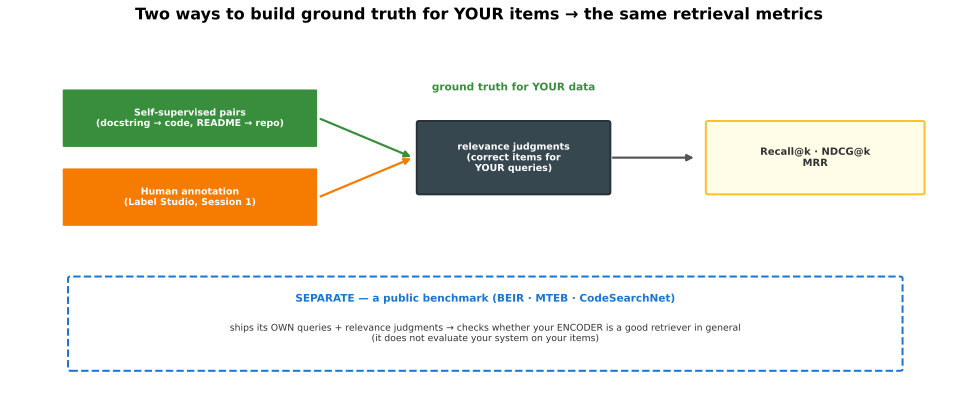

In [17]:
# Three routes to relevance judgments (qrels) when there is no user log -> the SAME retrieval metrics.
fig, ax = plt.subplots(figsize=(13.5, 5.8)); ax.axis('off')
ax.set_xlim(0, 15); ax.set_ylim(0, 8)

def _gb(cx, cy, w, h, t, fc, ec, fs=10.5, tc='white'):
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h, boxstyle='round,pad=0.04',
                                facecolor=fc, edgecolor=ec, lw=2))
    ax.text(cx, cy, t, ha='center', va='center', fontsize=fs, fontweight='bold', color=tc)

def _ga(x0, y0, x1, y1, col='#555'):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle='-|>', color=col, lw=2.2))

# top: the TWO routes that build qrels for YOUR data -> qrels -> the same metrics
srcs = [('Self-supervised pairs\n(docstring → code, README → repo)', GREEN,  6.0),
        ('Human annotation\n(Label Studio, Session 1)',              ORANGE, 4.3)]
for t, col, y in srcs:
    _gb(2.9, y, 4.0, 1.2, t, col, 'white', 9.4)
    _ga(4.95, y, 6.45, 5.15, col)
_gb(8.05, 5.15, 3.0, 1.5, 'relevance judgments\n(correct items for\nYOUR queries)', '#37474f', '#263238', 9.5)
_ga(9.6, 5.15, 10.95, 5.15)
_gb(12.85, 5.15, 3.4, 1.5, 'Recall@k · NDCG@k\nMRR', '#fffde7', '#fbc02d', 10, '#333')
ax.text(8.05, 6.6, 'ground truth for YOUR data', ha='center', fontsize=10.5, color=GREEN, fontweight='bold')

# bottom (separate, dashed): a public benchmark tests the ENCODER on its OWN data — not your items
ax.add_patch(FancyBboxPatch((1.0, 0.6), 13.2, 1.95, boxstyle='round,pad=0.04',
                            fill=False, edgecolor=BLUE, lw=2, linestyle='--'))
ax.text(7.6, 2.05, 'SEPARATE — a public benchmark (BEIR · MTEB · CodeSearchNet)',
        ha='center', fontsize=10.5, color=BLUE, fontweight='bold')
ax.text(7.6, 1.2, 'ships its OWN queries + relevance judgments → checks whether your ENCODER is a good retriever in general\n'
        '(it does not evaluate your system on your items)', ha='center', fontsize=9.3, color='#333')

ax.set_title('Two ways to build ground truth for YOUR items → the same retrieval metrics', fontweight='bold')
plt.tight_layout(); plt.show()

> A **public benchmark** is a *different tool* (slide after next): it ships its **own** queries + relevance
> judgments, so it tests whether your **encoder** is a good retriever *in general* — **not** your system on
> *your* items. **[MRR](https://en.wikipedia.org/wiki/Mean_reciprocal_rank)** (*Mean Reciprocal Rank*), *in one
> sentence:* if the first correct hit sits at rank *r* the query scores $1/r$ (rank 1 → 1.0, rank 2 → 0.5, …),
> averaged over all queries.

## Building relevance judgments by hand (Label Studio)

<small><span style="color:#1976d2"><b>Awareness</b></span> — appreciate the idea, don't memorize the internals.</small>

- When no natural pairs exist (or you want *real* relevance): write ~30–50 representative **queries**,
  retrieve candidates, and label each (query, item) **relevant / not** — graded 0–3 if you want NDCG.
- This is exactly the **Label Studio** pipeline from **Session 1 (Data Acquisition)** — same tool, now
  labeling *(query, document)* pairs instead of raw records.
- **Pooling** keeps it affordable: judge only the **top-k of a few systems**, treat everything unjudged as
  not-relevant.

> Use ≥2 annotators and report **inter-annotator agreement** (Cohen's / Fleiss' κ, also from Session 1):
> if humans can't agree on what's relevant, the metric is just noise. And the labels, though gold, are
> **incomplete** — an unjudged-but-relevant item is scored as a miss (the same *missing-not-at-random*
> caveat from the last slide).

## Public benchmarks — sanity-check the *encoder*

<small><span style="color:#1976d2"><b>Awareness</b></span> — appreciate the idea, don't memorize the internals.</small>

- A **different question**: not "is my *system* good on *my* data?" but "**is my *encoder* a good retriever at
  all?**" Run it on a benchmark that **already ships queries + relevance judgments** — match the **task shape** to your project:
  - **text retrieval** → **BEIR** (zero-shot, 18 datasets), **MTEB** (the embedding leaderboard), **MS MARCO**, **Natural Questions**
  - **code search** → **CodeSearchNet**, **CoIR**
  - **image ↔ text** → **MS COCO** · **Flickr30K** (caption↔image retrieval), **ImageNet** (CLIP zero-shot), **MMEB / MIEB** (multimodal leaderboards)
- The pipeline is a few lines (it downloads the data, so run it offline — not in this notebook):

```python
import mteb
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")        # your encoder (a CLIP model for image↔text)
tasks = mteb.get_tasks(tasks=["SciFact", "NFCorpus"])  # pick benchmark tasks by name
results = mteb.MTEB(tasks=tasks).run(model)            # downloads, embeds, scores → NDCG@10 · Recall@k · MRR
```

> A benchmark tests the **encoder** on *its* data, not your **system** on *your* items — so report a
> public-benchmark number **and** a small hand-labeled set from your own data. **MTEB / BEIR** are also where
> you'd **pick** which pretrained encoder to start from.

## Wrap-up: everything became a vector — in one space

**The whole course, in one line:**

- **S6** framed the problem — sparsity, the long tail, **cold-start**.
- **S7 → S9** turned **genres → ratings → text** into **vectors** (content-based, matrix factorization, neural embeddings).
- **S10, today:** **images** joined them — a movie's plot, its poster, and its audience now all live in **one shared space**.

**The one idea under all of it:** every method turns users and items into **vectors in one shared space** and ranks them by a **dot product** — whether that vector comes from a trained **encoder** (text, images), a **learned lookup** (SVD, autoencoder), or simply **averaging item features** (content). One **evaluation harness** then scores them all head-to-head.

Once both sides are vectors, **recommending and searching run on the same machinery** — nearest-neighbour retrieval — even though the questions they answer differ.

> One honest caveat to take with you: offline metrics are only a **proxy** (ratings are *missing-not-at-random*
> — people rate what they were shown), so the real test is **online** — clicks, dwell time, A/B tests.